# Chapter 2. Smoothing filters

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import libraries

To install libraries in Python, you can use a package manager like pip, which comes pre-installed with most Python distributions.



In [3]:
from matplotlib import pyplot as plt
import pandas as pd
from scipy import signal

## Import Dataset
просто кузкат ьадресмс дял всех датесвов что есть

In [4]:
# load the Excel file as a DataFrame
emg_data_1 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_1.xlsx")
emg_data_2 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_2.xlsx")
emg_data_3 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_3.xlsx")
emg_data_4 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_4.xlsx")
emg_data_5 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_5.xlsx")
emg_data_6 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_6.xlsx")
emg_data_7 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_7.xlsx")
emg_data_8 = pd.read_excel("/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL//EMG_dataset/subject_8.xlsx")


#display(eeg_demg_data_8ata.head())

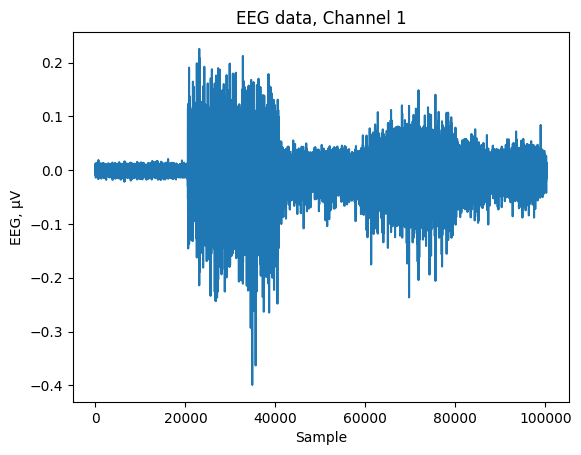

In [5]:
# select the data from the first channel
channel = 0
channel_data = emg_data_8.iloc[:, channel]
# plot the EEG data
plt.plot(channel_data)
plt.title("EEG data, Channel " + str(channel+1))
plt.ylabel('EEG, µV')
plt.xlabel('Sample')
plt.show()

Нам надо точно знать а когда это проишоло???
потому датает надо это декттить для надо!!!

Combine data


In [6]:
import pandas as pd
import glob
import os

# Define the directory path matching your files
directory = "/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EMG_dataset/"

# Find all subject_*.xlsx files in the directory
file_pattern = os.path.join(directory, "subject_*.xlsx")
files = glob.glob(file_pattern)

# Read and combine all matching Excel files into a list of DataFrames
dfs = [pd.read_excel(f) for f in files]

# Concatenate all DataFrames into one
combined_eeg_data = pd.concat(dfs, ignore_index=True)
print (combined_eeg_data)

             Ch1       Ch2       Ch3       Ch4  Gesture
0       0.012060  0.007172 -0.004912 -0.010352        0
1       0.009734  0.002081 -0.005152 -0.015085        0
2       0.009581  0.001323  0.000032 -0.014105        0
3       0.008355  0.006496  0.000987 -0.011838        0
4       0.005473  0.002169  0.004220 -0.009029        0
...          ...       ...       ...       ...      ...
822686  0.005349  0.051188 -0.004612 -0.078479        4
822687 -0.003400  0.045711 -0.031460  0.057762        4
822688 -0.008356  0.027660 -0.006860  0.065028        4
822689 -0.014089  0.010258  0.007897 -0.051703        4
822690 -0.010966  0.005727 -0.008867 -0.079172        4

[822691 rows x 5 columns]


**Machine Learing**

This script implements an EMG-based gesture recognition pipeline by processing raw EMG signals from multiple channels, extracting time-domain features (mean absolute value, standard deviation, RMS, range, waveform length) using a sliding window approach, and assigning gesture labels to each window. The extracted features are standardized and used to train a Random Forest classifier, which is then evaluated for accuracy and detailed performance metrics. Finally, the trained model and scaler are saved for future real-time gesture prediction, enabling automated identification of hand or muscle gestures from EMG data.


100 выборок   как много дана брать для EMG

**Смешать данные**

**Step 1: Split your dataset into 2-second chunks**

In [7]:
import numpy as np
import pandas as pd
block_size = 200

**Step 2: Shuffle the chunks**

In [8]:
# Number of complete blocks we can have
num_blocks = len(combined_eeg_data) // block_size
# Trim excess rows so we have exact blocks
data_trimmed = combined_eeg_data.iloc[:num_blocks * block_size]
# Split into blocks
blocks = np.array_split(data_trimmed, num_blocks)


/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


**Step 3: Flatten back to original shape**

In [9]:
np.random.shuffle(blocks)

**Concatenate back into a single DataFrame**

In [10]:
mixed_data = pd.concat(blocks).reset_index(drop=True)
print (mixed_data)

             Ch1       Ch2       Ch3       Ch4  Gesture
0       0.012496 -0.033154  0.026039 -0.019904        1
1      -0.008010 -0.036993  0.018729 -0.044292        1
2       0.018448 -0.032214  0.042768 -0.037858        1
3       0.032802 -0.026832  0.008710 -0.006905        1
4       0.027390 -0.011921  0.006333  0.073078        1
...          ...       ...       ...       ...      ...
822595  0.000794  0.005479 -0.001128  0.001296        0
822596  0.001137  0.004847  0.000906  0.003287        0
822597  0.000211  0.001897 -0.000179 -0.001082        0
822598  0.001570  0.002015 -0.002123  0.000955        0
822599  0.001954  0.000040 -0.007288 -0.001364        0

[822600 rows x 5 columns]


In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
import glob
import os

# Load combined EMG data (from previous script)
#directory = "/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EMG_dataset/"
combined_data =  mixed_data # combined_eeg_data #pd.read_excel(os.path.join(directory, "combined_subjects.xlsx"))

# Assume columns: timestamp, ch1-ch4 (EMG channels), gesture_label (adjust names as needed)
emg_channels = ['Ch1', 'Ch2', 'Ch3', 'Ch4']  # Update with your actual column names
X = combined_data[emg_channels].values
y = combined_data['Gesture'].values  # Update with your label column name

# Feature extraction functions for EMG
def extract_features(window):
    features = []
    # Time-domain features [web:11]
    features.append(np.mean(np.abs(window)))      # MAV
    features.append(np.std(window))               # STD
    features.append(np.sqrt(np.mean(window**2)))  # RMS
    features.append(np.max(np.abs(window)) - np.min(np.abs(window)))  # Range
    features.append(np.sum(np.diff(np.abs(window))**2))  # Waveform length
    return features

# Sliding window feature extraction (200ms windows, 50% overlap)
window_size = 200
stride = 100
features_list = []
labels_list = []

for i in range(0, len(X) - window_size, stride):
    window = X[i:i+window_size]
    if len(window) == window_size:
        feat = []
        for ch in window.T:  # Per channel features
            feat.extend(extract_features(ch))
        features_list.append(feat)
        labels_list.append(y[i + window_size//2])

X_features = np.array(features_list)
y_labels = np.array(labels_list)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_features, y_labels, test_size=0.3, random_state=42)


# Train Random Forest classifier (robust for EMG) [web:12][web:13]
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Evaluate
y_pred = clf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save model and scaler
# import joblib
# joblib.dump(clf, os.path.join(directory, 'emg_gesture_classifier.pkl'))
# joblib.dump(scaler, os.path.join(directory, 'emg_scaler.pkl'))
# print("Model saved!")


Accuracy: 0.744

Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.72      0.76       462
           1       0.70      0.90      0.79       452
           2       0.79      0.76      0.78       513
           3       0.71      0.69      0.70       510
           4       0.74      0.67      0.70       531

    accuracy                           0.74      2468
   macro avg       0.75      0.75      0.74      2468
weighted avg       0.75      0.74      0.74      2468



This second script also performs EMG-based gesture recognition but differs from the first by focusing on frequency-domain and power-based features rather than purely time-domain features. Each 1-second EMG window is processed to extract RMS, FFT-based band power, PSD in low/mid/high frequency bands, peak frequency, and mean frequency, capturing the spectral characteristics of muscle activity. These power and spectral features are then used to train a Random Forest classifier, evaluated for accuracy, and saved for future prediction. In contrast, the first script relied solely on time-domain features (mean, standard deviation, RMS, range, waveform length) extracted from shorter 200-ms overlapping windows.

In short:

First script: Time-domain EMG features, 200-ms windows, short-term signal characteristics.

Second script: Frequency/power-domain EMG features, 1-second windows, spectral characteristics.

In [15]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.fft import fft
from scipy.signal import welch
import glob
import os

# Load combined EMG data
directory = "/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EMG_dataset/"
combined_data =  mixed_data #combined_eeg_data # pd.read_excel(os.path.join(directory, "combined_subjects.xlsx"))

# EMG parameters: 250 Hz sampling, 1-sec windows = 250 samples
fs = 1000  # Hz
window_size = 200  # 1 second
emg_channels = ['Ch1', 'Ch2', 'Ch3', 'Ch4']  # Update with your actual column names
label_col = 'Gesture'  # Update label column name

def calculate_emg_power_features(window, fs):
    """Calculate EMG frequency power features for 1-sec window - FIXED [web:31]"""
    features = []

    # 1. Total RMS power (time-domain baseline)
    rms = np.sqrt(np.mean(window**2))
    features.append(rms)

    # 2. FFT-based power in EMG frequency bands (20-500 Hz) - FIXED INDEX MISMATCH
    N = len(window)
    fft_vals = np.abs(fft(window))
    freq = np.fft.fftfreq(N, 1/fs)

    # Only use positive frequencies (first half)
    pos_freq = freq[:N//2]
    fft_pos = fft_vals[:N//2]

    emg_band = (pos_freq >= 20) & (pos_freq <= 500)
    emg_power = np.sum(fft_pos[emg_band]**2) / N  # Power spectral density
    features.append(np.sqrt(emg_power))  # Band power RMS

    # 3. PSD using Welch method - power in key EMG bands
    f, psd = welch(window, fs, nperseg=window_size)

    # Band powers: Low (20-50 Hz), Mid (50-150 Hz), High (150-400 Hz)
    low_band = (f >= 20) & (f <= 50)
    mid_band = (f >= 50) & (f <= 150)
    high_band = (f >= 150) & (f <= 400)

    features.append(np.sum(psd[low_band]))      # Low freq power
    features.append(np.sum(psd[mid_band]))      # Mid freq power
    features.append(np.sum(psd[high_band]))     # High freq power
    features.append(np.mean(psd[(f >= 20) & (f <= 500)]))  # Mean PSD in EMG range

    # 4. Spectral features
    emg_psd_mask = (f >= 20) & (f <= 500)
    features.append(np.argmax(psd[emg_psd_mask]))   # Peak frequency index
    features.append(np.sum(f[emg_psd_mask] * psd[emg_psd_mask]) / np.sum(psd[emg_psd_mask]))  # Mean frequency

    return features

# Extract 1-sec power features (non-overlapping for clean segments)
X_power_features = []
y_labels = []

for i in range(0, len(combined_data) - window_size, window_size):
    window_data = combined_data[emg_channels].iloc[i:i+window_size].values
    window_labels = combined_data[label_col].iloc[i:i+window_size]

    if len(window_data) == window_size and len(np.unique(window_labels)) == 1:
        label = window_labels.iloc[0]
        feat_vector = []

        # Power features per channel
        for ch in range(window_data.shape[1]):  # Use actual number of channels
            feat_vector.extend(calculate_emg_power_features(window_data[:, ch], fs))

        X_power_features.append(feat_vector)
        y_labels.append(label)

X_features = np.array(X_power_features)
y = np.array(y_labels)
print (X_features, "x")
print (y, "y")
print(f"Extracted {X_features.shape[0]} clean 1-sec segments with {X_features.shape[1]} power features")

# Train Random Forest classifier
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

# Results
y_pred = clf.predict(X_test_scaled)
print(f"EMG Power Feature Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save everything
import joblib
joblib.dump(clf, os.path.join(directory, 'emg_power_rf_classifier.pkl'))
joblib.dump(scaler, os.path.join(directory, 'emg_power_scaler.pkl'))
print("EMG Power-based Gesture Classifier saved!")


[[5.66110970e-02 5.64172684e-01 1.88326491e-04 ... 9.16546502e-06
  6.00000000e+00 1.27777756e+02]
 [5.79023914e-03 5.24076665e-02 1.34715919e-06 ... 1.42339592e-08
  4.00000000e+00 1.43216240e+02]
 [3.29091601e-02 3.25525511e-01 1.07820669e-04 ... 6.82521573e-06
  8.00000000e+00 8.13309029e+01]
 ...
 [1.39742874e-02 1.38617299e-01 9.63073674e-06 ... 1.36533324e-06
  2.40000000e+01 1.16606944e+02]
 [1.74990207e-02 1.74503994e-01 5.41120384e-06 ... 1.76720537e-07
  5.00000000e+00 1.11340572e+02]
 [3.96374216e-02 3.95735054e-01 2.48943316e-05 ... 3.15262911e-05
  8.00000000e+00 1.23812172e+02]] x
[1 0 3 ... 2 2 1] y
Extracted 4073 clean 1-sec segments with 32 power features
EMG Power Feature Accuracy: 0.953

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       244
           1       0.97      0.95      0.96       241
           2       0.98      1.00      0.99       261
           3       0.91      0.87      0.89 

power and mix and Random forest

DL LSTM
The previous script uses a traditional machine-learning approach, where raw EMG signals are first converted into handcrafted time- and frequency-domain features and then classified using a Random Forest model, whereas the new script adopts a deep learning approach (LSTM) that operates directly on raw EMG time-series data and automatically learns temporal and inter-channel patterns without explicit feature engineering.

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler
from scipy.fft import fft
from scipy.signal import welch
import glob
import os

# Load combined EMG data
directory = "/content/drive/MyDrive/Book_AI_for_Bio_Science/Scripts/dataset/ML_DL/EMG_dataset/"
combined_data =  mixed_data #combined_eeg_data # pd.read_excel(os.path.join(directory, "combined_subjects.xlsx"))

# EMG parameters: 250 Hz sampling, 1-sec windows = 250 samples
fs = 1000  # Hz
window_size = 200  # 1 second
emg_channels = ['Ch1', 'Ch2', 'Ch3', 'Ch4']  # Update with your actual column names
label_col = 'Gesture'  # Update label column name

def calculate_emg_power_features(window, fs):
    """Calculate EMG frequency power features for 1-sec window - FIXED [web:31]"""
    features = []

    # 1. Total RMS power (time-domain baseline)
    rms = np.sqrt(np.mean(window**2))
    features.append(rms)

    # 2. FFT-based power in EMG frequency bands (20-500 Hz) - FIXED INDEX MISMATCH
    N = len(window)
    fft_vals = np.abs(fft(window))
    freq = np.fft.fftfreq(N, 1/fs)

    # Only use positive frequencies (first half)
    pos_freq = freq[:N//2]
    fft_pos = fft_vals[:N//2]

    emg_band = (pos_freq >= 20) & (pos_freq <= 500)
    emg_power = np.sum(fft_pos[emg_band]**2) / N  # Power spectral density
    features.append(np.sqrt(emg_power))  # Band power RMS

    # 3. PSD using Welch method - power in key EMG bands
    f, psd = welch(window, fs, nperseg=window_size)

    # Band powers: Low (20-50 Hz), Mid (50-150 Hz), High (150-400 Hz)
    low_band = (f >= 20) & (f <= 50)
    mid_band = (f >= 50) & (f <= 150)
    high_band = (f >= 150) & (f <= 400)

    features.append(np.sum(psd[low_band]))      # Low freq power
    features.append(np.sum(psd[mid_band]))      # Mid freq power
    features.append(np.sum(psd[high_band]))     # High freq power
    features.append(np.mean(psd[(f >= 20) & (f <= 500)]))  # Mean PSD in EMG range

    # 4. Spectral features
    emg_psd_mask = (f >= 20) & (f <= 500)
    features.append(np.argmax(psd[emg_psd_mask]))   # Peak frequency index
    features.append(np.sum(f[emg_psd_mask] * psd[emg_psd_mask]) / np.sum(psd[emg_psd_mask]))  # Mean frequency

    return features

# Extract 1-sec power features (non-overlapping for clean segments)
X_power_features = []
y_labels = []

for i in range(0, len(combined_data) - window_size, window_size):
    window_data = combined_data[emg_channels].iloc[i:i+window_size].values
    window_labels = combined_data[label_col].iloc[i:i+window_size]

    if len(window_data) == window_size and len(np.unique(window_labels)) == 1:
        label = window_labels.iloc[0]
        feat_vector = []

        # Power features per channel
        for ch in range(window_data.shape[1]):  # Use actual number of channels
            feat_vector.extend(calculate_emg_power_features(window_data[:, ch], fs))

        X_power_features.append(feat_vector)
        y_labels.append(label)

X_features = np.array(X_power_features)
y = np.array(y_labels)
print (x, "x")
print (y, "y")
print(f"Extracted {X_features.shape[0]} clean 1-sec segments with {X_features.shape[1]} power features")

# Train Random Forest classifier
X_train, X_test, y_train, y_test = train_test_split(X_features, y, test_size=0.3, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
clf.fit(X_train_scaled, y_train)

# Results
y_pred = clf.predict(X_test_scaled)
print(f"EMG Power Feature Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save everything
import joblib
joblib.dump(clf, os.path.join(directory, 'emg_power_rf_classifier.pkl'))
joblib.dump(scaler, os.path.join(directory, 'emg_power_scaler.pkl'))
print("EMG Power-based Gesture Classifier saved!")


NameError: name 'x' is not defined

**LSTM**

**The end of the chapter 2**